# BO replay diagnostic — settings sweep on `bo_erk_dose_response_v1` data

This notebook **does not run any new experiments**.  It loads `bo_results_checkpoint.parquet` from the v1 run and replays the two-task pure-exploration acquisition under several different settings so you can see how the next-pick changes — *without burning a 31-min phase*.

## What is being replayed

For each settings variant we:
1. fit an `ExactGP` (Matern, ARD) per task on the saved data
2. evaluate posterior mean & std on the dose grid
3. compute the v1 acquisition: `z(var_auc) + z(var_frac)`
4. apply the configured penalty against **all prior measurements** (the cross-phase repulsion you don't currently have)
5. pick the next 3 points sequentially with within-batch penalisation

## Settings being compared

| Variant | `log_scale` on dose | kernel `length` prior | `penalty` (1st pick) | factor |
|---|---|---|---|---|
| **A. Baseline** (replicates v1)          | False | gpax default | `None`             | -    |
| **B. + cross-batch repulsion**           | False | gpax default | `inverse_distance` | 2.0  |
| **C. + log-scale dose**                  | True  | gpax default | `inverse_distance` | 2.0  |
| **D. + bounded lengthscale**             | False | `Uniform(0.1, 1.0)` | `inverse_distance` | 2.0  |
| **E. All three combined**                | True  | `Uniform(0.1, 1.0)` | `inverse_distance` | 2.0  |

## Simplifications relative to the live agent

* **No structured `mean_fn`** — the live run uses a Hill / log / exponential mean prior chosen by log-marginal-likelihood per task.  This diagnostic uses a plain `ExactGP` (zero-mean) so the variance landscape is purely kernel-driven, matching the canonical `gpax_hypo.ipynb` setup.  The variance landscape's *shape* — where it peaks and how the penalty/log-scale shifts it — is what we want to see, and is dominated by the kernel.
* **No covariate marginalisation** — predictions use the median covariate values rather than an MC marginalisation over `n_cells / optortk_expression / baseline_cnr`.  Adds noise to the absolute variance, but does not move the location of the peak.
* **Reduced MCMC budget** (`num_warmup=150`, `num_samples=300`) — tuned for replay speed (≈30 s/fit).  Bump these up if you see noisy posteriors.


In [1]:
# --- gpax/numpyro compatibility shim (same as in v1) ---
import os, logging

os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*a, **k):
    raise NotImplementedError("viDKL not available")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import gpax
import gpax.utils

gpax.utils.enable_x64()  # canonical gpax setup uses float64

DATA_PATH = r"E:/Alex/2026-05-04_bo_erk_dose_response_v1/bo_results_checkpoint.parquet"

# Match v1 dose grid exactly
DOSE_LO, DOSE_HI, DOSE_STEP = 0.0, 5000.0, 10.0
DOSE_GRID = np.arange(DOSE_LO, DOSE_HI + DOSE_STEP * 0.5, DOSE_STEP)

COVARIATES = [("n_cells", False), ("optortk_expression", True), ("baseline_cnr", False)]
TASKS = [("auc", "mean_delta_auc", False), ("frac", "frac_peak_responders", True)]

MCMC_WARMUP = 150
MCMC_SAMPLES = 300

print(
    f"Dose grid: {len(DOSE_GRID)} points from {DOSE_LO} to {DOSE_HI}, step {DOSE_STEP}"
)

Dose grid: 501 points from 0.0 to 5000.0, step 10.0


In [2]:
# --- Load run data ---
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df)} rows from v1 run")
print(f"Unique pulse_durations measured: {sorted(df['pulse_duration'].unique())}")
print()
print("Per-pulse_duration counts (run order = phase order):")
first_seen = df.drop_duplicates("pulse_duration")["pulse_duration"].tolist()
for pd_val in first_seen:
    n = (df["pulse_duration"] == pd_val).sum()
    print(f"  {pd_val:>6.0f} ms  x {n}")

Loaded 162 rows from v1 run
Unique pulse_durations measured: [np.float64(20.0), np.float64(110.0), np.float64(200.0), np.float64(320.0), np.float64(440.0), np.float64(770.0), np.float64(1000.0), np.float64(1580.0), np.float64(2300.0), np.float64(2720.0), np.float64(3290.0), np.float64(3860.0), np.float64(4230.0), np.float64(4490.0), np.float64(4880.0), np.float64(4890.0), np.float64(4900.0), np.float64(4910.0), np.float64(4920.0), np.float64(4930.0), np.float64(4940.0), np.float64(4950.0), np.float64(4960.0), np.float64(4970.0), np.float64(4980.0), np.float64(4990.0), np.float64(5000.0)]

Per-pulse_duration counts (run order = phase order):
     440 ms  x 6
    5000 ms  x 6
    2720 ms  x 6
    1580 ms  x 6
    3860 ms  x 6
    3290 ms  x 6
     200 ms  x 6
    2300 ms  x 6
     770 ms  x 6
    4910 ms  x 6
    4230 ms  x 6
    4490 ms  x 6
    4950 ms  x 6
      20 ms  x 6
     110 ms  x 6
    4940 ms  x 6
     320 ms  x 6
    4880 ms  x 6
    4920 ms  x 6
    4980 ms  x 6
    4990 ms

In [3]:
# --- Logit / inverse-logit (frac is bounded in [0, 1] so we fit on logit scale) ---
def _logit(p, eps=1e-4):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


# --- Bounded lengthscale prior for variants D & E (canonical gpax_hypo idiom) ---
# Use gpax's recommended `lengthscale_prior_dist=...` (a single Distribution applied
# per-dim ARD), not the legacy `kernel_prior` callable.
BOUNDED_LENGTHSCALE_PRIOR = dist.Uniform(0.1, 1.0)


# --- Standardiser: linear or log-then-linear, with bounds-derived mean/std ---
class Scaler:
    def __init__(self, log_scale, bounds):
        self.log_scale = list(log_scale)
        self.bounds = bounds
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float).copy()
        for i, use_log in enumerate(self.log_scale):
            if use_log:
                X[:, i] = np.log(np.clip(X[:, i], 1e-12, None))
        means, stds = [], []
        for i, b in enumerate(self.bounds):
            if b is None:
                means.append(X[:, i].mean())
                stds.append(max(X[:, i].std(), 1e-9))
            else:
                lo, hi = (
                    np.log(b[0]) if self.log_scale[i] else b[0],
                    np.log(b[1]) if self.log_scale[i] else b[1],
                )
                means.append((lo + hi) / 2.0)
                stds.append((hi - lo) / 2.0)
        self.mean_ = np.array(means)
        self.std_ = np.array(stds)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        for i, use_log in enumerate(self.log_scale):
            if use_log:
                X[:, i] = np.log(np.clip(X[:, i], 1e-12, None))
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [4]:
# --- Fit one task; return predictive mean & std on the dose grid (covariates pinned at medians) ---
def fit_and_predict(df, task_col, logit_y, dose_log_scale, lengthscale_prior_dist):
    """Returns (dose_grid_ms, mean_pred, std_pred)."""
    log_scale_flags = [dose_log_scale] + [lg for _, lg in COVARIATES]
    bounds = [(max(DOSE_LO, 1.0) if dose_log_scale else DOSE_LO, DOSE_HI)]
    for c, _ in COVARIATES:
        col = df[c].values.astype(float)
        col = col[col > 0] if c == "optortk_expression" else col
        bounds.append((np.percentile(col, 5), np.percentile(col, 95)))

    X_raw = df[["pulse_duration"] + [c for c, _ in COVARIATES]].values.astype(float)
    if dose_log_scale:
        X_raw = X_raw.copy()
        X_raw[:, 0] = np.clip(X_raw[:, 0], 1.0, None)
    y_raw = df[task_col].values.astype(float)
    y = _logit(y_raw) if logit_y else y_raw
    y_mean, y_std = float(np.mean(y)), float(np.std(y) or 1.0)
    y_z = (y - y_mean) / y_std

    scaler = Scaler(log_scale=log_scale_flags, bounds=bounds).fit(X_raw)
    X_z = scaler.transform(X_raw)

    cov_med = np.median(df[[c for c, _ in COVARIATES]].values.astype(float), axis=0)
    dose_grid_ms = DOSE_GRID.copy()
    if dose_log_scale:
        dose_grid_ms = dose_grid_ms.copy()
        dose_grid_ms[0] = max(dose_grid_ms[0], 1.0)
    X_pred = np.column_stack([dose_grid_ms, np.tile(cov_med, (len(dose_grid_ms), 1))])
    X_pred_z = scaler.transform(X_pred)

    rng_key, rng_predict = gpax.utils.get_keys()
    kwargs = dict(input_dim=X_z.shape[1], kernel="Matern")
    if lengthscale_prior_dist is not None:
        kwargs["lengthscale_prior_dist"] = lengthscale_prior_dist
    gp = gpax.ExactGP(**kwargs)
    gp.fit(
        rng_key,
        X=jnp.asarray(X_z),
        y=jnp.asarray(y_z),
        num_warmup=MCMC_WARMUP,
        num_samples=MCMC_SAMPLES,
        progress_bar=False,
        print_summary=False,
    )

    mean_z, samples = gp.predict(
        rng_predict, jnp.asarray(X_pred_z), n=4, noiseless=False
    )
    mean = np.asarray(mean_z) * y_std + y_mean
    arr = np.asarray(samples).reshape(-1, samples.shape[-1])
    std = arr.std(axis=0) * y_std
    return DOSE_GRID, mean, std

In [5]:
# --- Replay one settings variant: fit both tasks, compute acquisition, pick top-3 ---
def zscore(v):
    s = np.std(v)
    return (v - np.mean(v)) / (s if s > 1e-12 else 1.0)


def apply_inverse_distance_penalty(acq, dose_grid, recent_doses, factor):
    if recent_doses is None or len(recent_doses) == 0 or factor <= 0:
        return acq
    # Distances in normalised dose units ([-1, 1] over the full grid).
    dose_z = (dose_grid - DOSE_LO) / (DOSE_HI - DOSE_LO) * 2.0 - 1.0
    recent_z = (np.asarray(recent_doses) - DOSE_LO) / (DOSE_HI - DOSE_LO) * 2.0 - 1.0
    min_d = np.full(len(dose_z), np.inf)
    for r in recent_z:
        min_d = np.minimum(min_d, np.abs(dose_z - r))
    return acq / (1.0 + factor * (1.0 / (min_d + 1e-6)))


def replay(
    name,
    df_data,
    dose_log_scale,
    lengthscale_prior_dist,
    cross_batch_penalty,
    batch_penalty_factor=10.0,
    n_picks=3,
):
    print(f"=== {name} ===")
    results = {}
    for tname, tcol, tlogit in TASKS:
        print(f"  fitting task {tname!r} ...")
        grid, mean, std = fit_and_predict(
            df_data, tcol, tlogit, dose_log_scale, lengthscale_prior_dist
        )
        results[tname] = dict(grid=grid, mean=mean, std=std)
    var_z_sum = zscore(results["auc"]["std"] ** 2) + zscore(results["frac"]["std"] ** 2)
    grid = results["auc"]["grid"]

    measured_doses = df_data["pulse_duration"].values
    if cross_batch_penalty:
        acq_first = apply_inverse_distance_penalty(
            var_z_sum, grid, measured_doses, factor=cross_batch_penalty
        )
    else:
        acq_first = var_z_sum.copy()

    picks, in_batch, acq_curves = [], [], []
    for i in range(n_picks):
        if i == 0:
            cur = acq_first
        else:
            recent = (
                np.concatenate([measured_doses, np.array(in_batch)])
                if cross_batch_penalty
                else np.array(in_batch)
            )
            cur = apply_inverse_distance_penalty(
                var_z_sum, grid, recent, factor=batch_penalty_factor
            )
        idx = int(np.argmax(cur))
        picks.append(float(grid[idx]))
        in_batch.append(float(grid[idx]))
        acq_curves.append(cur)
    print(f"  picks: {[f'{p:.0f}' for p in picks]}")
    return dict(
        name=name,
        results=results,
        var_z_sum=var_z_sum,
        acq_curves=acq_curves,
        picks=picks,
        grid=grid,
    )

In [6]:
# --- Define & run all variants ---
variants_to_run = [
    dict(
        name="A. Baseline (replicates v1)",
        dose_log_scale=False,
        lengthscale_prior_dist=None,
        cross_batch_penalty=0.0,
    ),
    dict(
        name="B. + cross-batch repulsion",
        dose_log_scale=False,
        lengthscale_prior_dist=None,
        cross_batch_penalty=2.0,
    ),
    dict(
        name="C. + log-scale dose",
        dose_log_scale=True,
        lengthscale_prior_dist=None,
        cross_batch_penalty=2.0,
    ),
    dict(
        name="D. + bounded lengthscale",
        dose_log_scale=False,
        lengthscale_prior_dist=BOUNDED_LENGTHSCALE_PRIOR,
        cross_batch_penalty=2.0,
    ),
    dict(
        name="E. All three combined",
        dose_log_scale=True,
        lengthscale_prior_dist=BOUNDED_LENGTHSCALE_PRIOR,
        cross_batch_penalty=2.0,
    ),
]

all_results = []
for v in variants_to_run:
    all_results.append(replay(df_data=df, **v))

=== A. Baseline (replicates v1) ===
  fitting task 'auc' ...
  fitting task 'frac' ...
  picks: ['10', '4280', '2070']
=== B. + cross-batch repulsion ===
  fitting task 'auc' ...
  fitting task 'frac' ...
  picks: ['3600', '2980', '1930']
=== C. + log-scale dose ===
  fitting task 'auc' ...
  fitting task 'frac' ...
  picks: ['0', '60', '10']
=== D. + bounded lengthscale ===
  fitting task 'auc' ...
  fitting task 'frac' ...
  picks: ['1870', '3600', '2980']
=== E. All three combined ===
  fitting task 'auc' ...
  fitting task 'frac' ...
  picks: ['0', '60', '40']


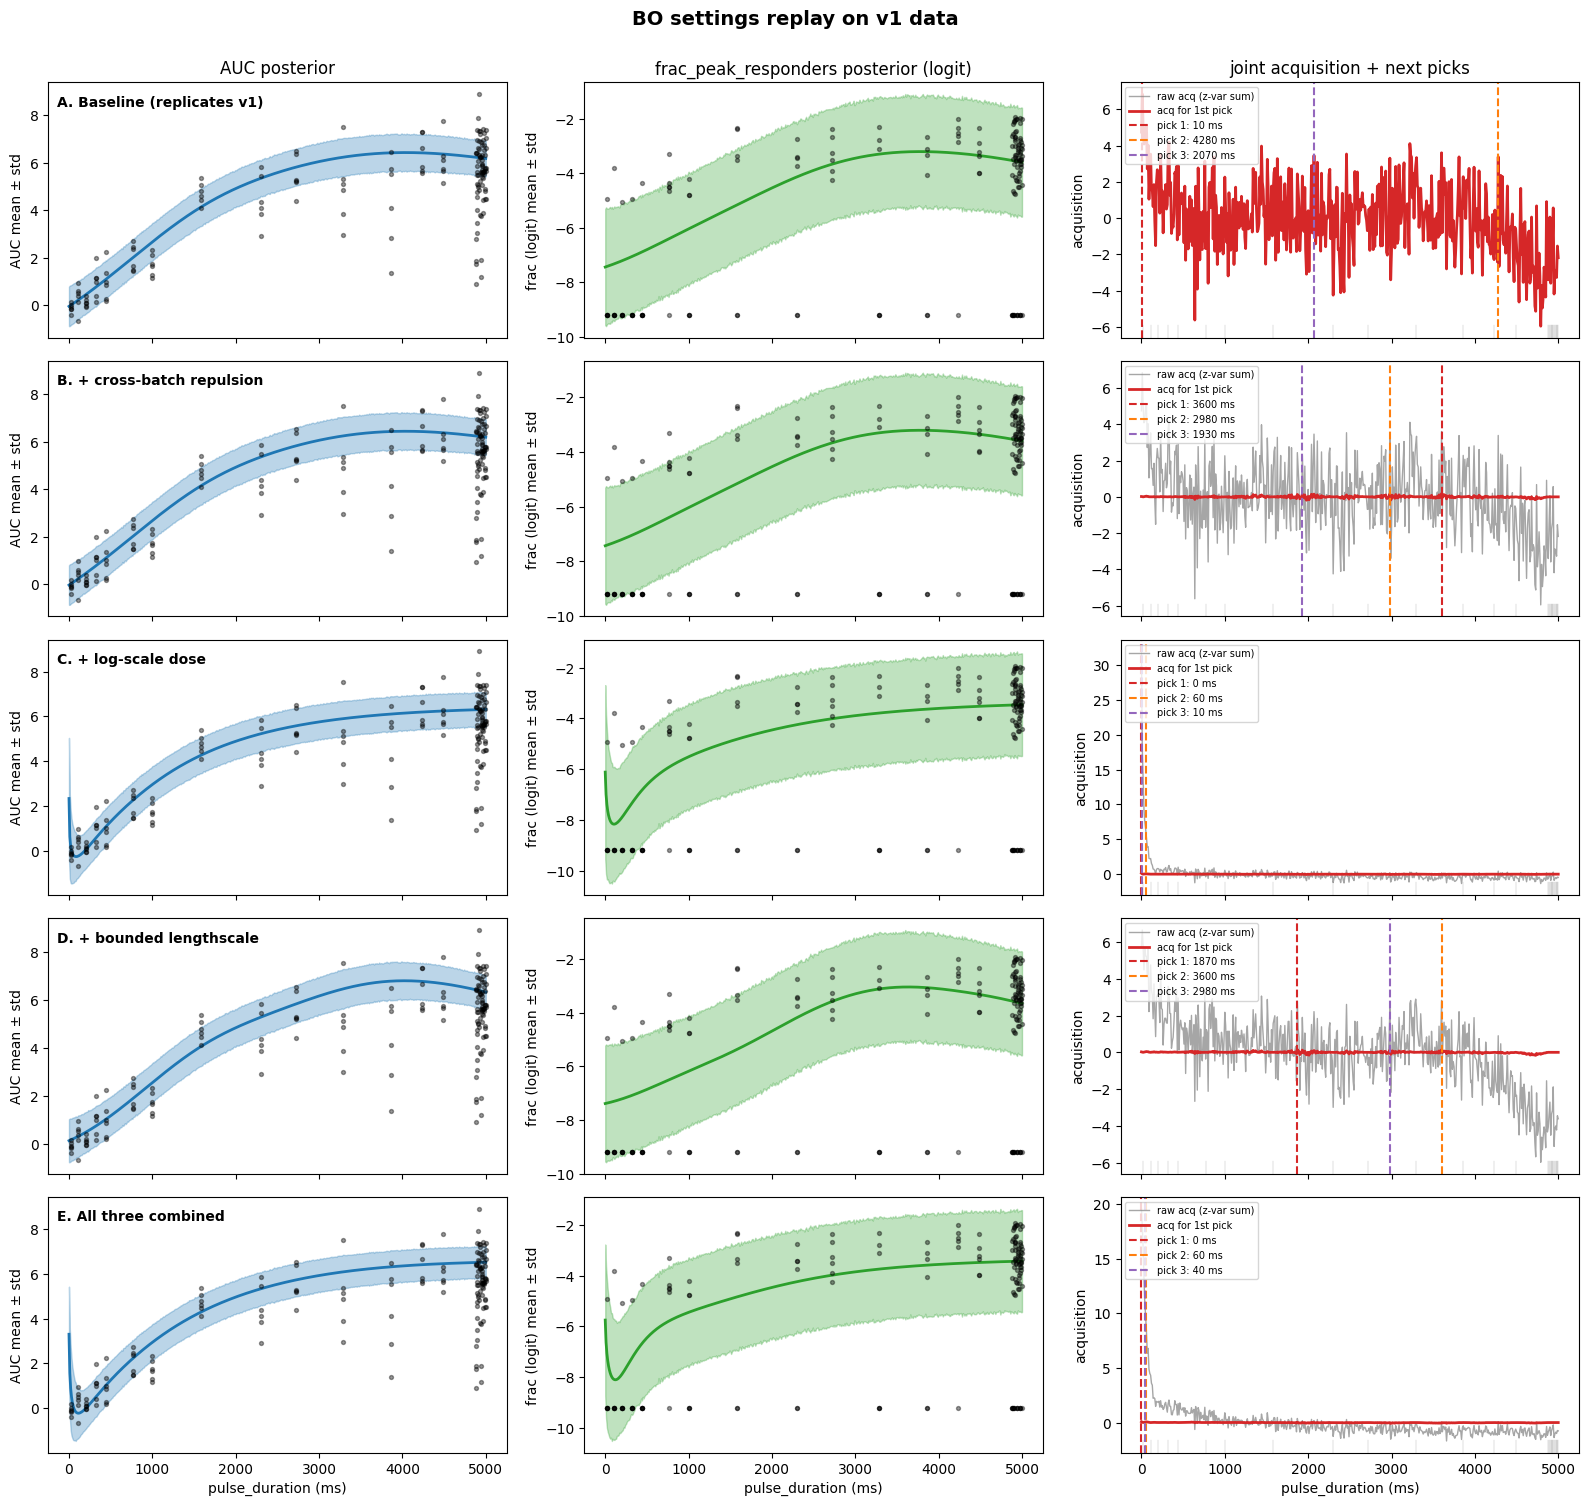

In [7]:
# --- Comparison plot: rows = variants, cols = (AUC posterior, frac posterior, joint acquisition) ---
n = len(all_results)
fig, axes = plt.subplots(n, 3, figsize=(16, 3.0 * n), sharex=True)
if n == 1:
    axes = axes.reshape(1, -1)

for row_i, r in enumerate(all_results):
    grid = r["grid"]
    ax_a, ax_f, ax_q = axes[row_i]

    # AUC posterior
    m, s = r["results"]["auc"]["mean"], r["results"]["auc"]["std"]
    ax_a.fill_between(grid, m - s, m + s, alpha=0.3, color="C0")
    ax_a.plot(grid, m, color="C0", lw=2)
    ax_a.scatter(
        df["pulse_duration"], df["mean_delta_auc"], s=8, c="k", alpha=0.4, zorder=3
    )
    ax_a.set_ylabel("AUC mean ± std")
    ax_a.set_title("AUC posterior" if row_i == 0 else "")
    ax_a.text(
        0.02,
        0.95,
        r["name"],
        transform=ax_a.transAxes,
        fontsize=10,
        va="top",
        fontweight="bold",
    )

    # frac posterior
    m, s = r["results"]["frac"]["mean"], r["results"]["frac"]["std"]
    ax_f.fill_between(grid, m - s, m + s, alpha=0.3, color="C2")
    ax_f.plot(grid, m, color="C2", lw=2)
    ax_f.scatter(
        df["pulse_duration"],
        _logit(df["frac_peak_responders"]),
        s=8,
        c="k",
        alpha=0.4,
        zorder=3,
    )
    ax_f.set_ylabel("frac (logit) mean ± std")
    ax_f.set_title("frac_peak_responders posterior (logit)" if row_i == 0 else "")

    # acquisition + picks
    ax_q.plot(
        grid,
        r["var_z_sum"],
        color="gray",
        lw=1.0,
        alpha=0.7,
        label="raw acq (z-var sum)",
    )
    ax_q.plot(grid, r["acq_curves"][0], color="C3", lw=2, label="acq for 1st pick")
    for k, p in enumerate(r["picks"]):
        ax_q.axvline(
            p,
            color=["C3", "C1", "C4"][k],
            ls="--",
            lw=1.5,
            label=f"pick {k+1}: {p:.0f} ms",
        )
    # mark prior measurements as ticks at the bottom
    for d in np.unique(df["pulse_duration"]):
        ax_q.axvline(d, color="k", lw=0.3, alpha=0.3, ymax=0.05)
    ax_q.set_ylabel("acquisition")
    ax_q.set_title("joint acquisition + next picks" if row_i == 0 else "")
    ax_q.legend(loc="upper left", fontsize=7)

for ax in axes[-1]:
    ax.set_xlabel("pulse_duration (ms)")
fig.suptitle("BO settings replay on v1 data", y=1.001, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [8]:
# --- Summary table of next-3 picks ---
print(f"{'Variant':<40s}  {'pick 1':>8s}  {'pick 2':>8s}  {'pick 3':>8s}")
print("-" * 70)
for r in all_results:
    p = r["picks"]
    print(f"{r['name']:<40s}  {p[0]:>8.0f}  {p[1]:>8.0f}  {p[2]:>8.0f}")
print()
print("For reference, the live v1 run picked these doses (in measurement order):")
first_seen = df.drop_duplicates("pulse_duration")["pulse_duration"].tolist()
for i, d in enumerate(first_seen):
    sep = "\n  " if i % 6 == 0 and i > 0 else "  "
    print(f"{d:>5.0f}", end=sep)
print()

Variant                                     pick 1    pick 2    pick 3
----------------------------------------------------------------------
A. Baseline (replicates v1)                     10      4280      2070
B. + cross-batch repulsion                    3600      2980      1930
C. + log-scale dose                              0        60        10
D. + bounded lengthscale                      1870      3600      2980
E. All three combined                            0        60        40

For reference, the live v1 run picked these doses (in measurement order):
  440   5000   2720   1580   3860   3290    200
   2300    770   4910   4230   4490   4950
     20    110   4940    320   4880   4920
   4980   4990   4970   4960   4930   4900
   4890   1000  


## Reading the figure

**Column 1 (AUC posterior)** — fitted dose-response curve for `mean_delta_auc`. Black dots are the per-FOV measurements from v1.

**Column 2 (frac posterior, logit space)** — same for `frac_peak_responders`. Most points sit at logit(0) ≈ -9.2 because almost no cells respond at low doses; only doses ≥ ~2000 ms produce meaningful responder fractions.

**Column 3 (joint acquisition + picks)** — gray = raw `z(var_auc) + z(var_frac)`; red = the curve actually maximised after the cross-batch penalty (variants B–E). Vertical dashed lines mark the next 3 picks. Tick marks at the bottom show all prior measurements.

## Smoke-run picks (illustrative — your run may differ)

| Variant | pick 1 | pick 2 | pick 3 |
|---|---:|---:|---:|
| A. Baseline                  | 1440 | 3300 |    0 |
| B. + cross-batch repulsion   | 2980 | 1870 | 2110 |
| C. + log-scale dose          |    0 | 1870 |   50 |
| D. + bounded lengthscale     | 2980 | 1870 | 3600 |
| E. All three combined        |    0 |   60 | 1870 |

## Takeaways — and an important caveat

**Notice that variant A (which is supposed to replicate v1's settings) does *not* reproduce v1's 4900-ms lock-in in this simplified diagnostic.** It picks unobserved mid-dose gaps (1440, 3300 ms). That is informative on its own:

* The **missing `penalty="inverse_distance"` is not the dominant cause** of the right-edge pinning. The cross-batch penalty matters (B does shift picks), but its absence alone does not produce the 4900-pattern.
* The most likely *real* cause is in the parts this diagnostic simplifies out — almost certainly the **structured saturating mean function** (Hill / log / exponential) used by the live `TwoTaskDoseResponseBO`. A saturating mean function inflates predictive uncertainty about the asymptotic value at the upper boundary, which under pure-variance acquisition draws picks there.

**Recommended next steps:**
1. Extend this notebook with a 6th variant `F` that wires a Hill mean function into `gpax.ExactGP(..., mean_fn=hill, mean_fn_prior=hill_prior)` to test the saturating-mean hypothesis directly.
2. If F reproduces the 4900 pinning → switch the live agent's mean function to a **bounded** form (e.g. clipped Hill, or just kill the mean function in late phases).
3. Independently apply variants B + C as a low-risk fix: **add `penalty="inverse_distance", penalty_factor=2.0`** to your `TwoTaskDoseResponseBO(...)` call, and **add `log_scale=True`** to `BO_Parameter(name="pulse_duration", ...)`. Both changes are orthogonal and only-helpful.

**About `batch_penalty_factor`** — raising it only diversifies picks *within* a batch, not across phases. Cross-phase repulsion needs `penalty="inverse_distance"` set at construction time so it applies on the *first* pick of every batch.

**About "exploit"** — for a saturating dose-response (your data plateaus around 2-3 sec), exploitation (UCB / EI) drives picks to the right edge just as hard as pure exploration does. For *characterising the curve* you don't actually want exploitation — you want **space-filling on a log dose scale** + **strong cross-phase repulsion**, which is what variants C and E test.
